In [56]:
# Apples vs Tomatoes — Image Classification
# Dataset link- https://www.kaggle.com/datasets/samuelcortinhas/apples-or-tomatoes-image-classification/data
# This solution is created and owned by Fayaz_A.M.

# This notebook is designed for beginners who have little knowledge of CNNs and
# want to understand how image classification works on a real-world dataset

# We will start with a basic CNN and gradually improve its performance using:

# • Data preprocessing
# • CNN architecture
# • Batch Normalization
# • Dropout
# • Data Augmentation
# • Learning-rate tuning
# • Transfer Learning
# • Fine-Tuning

# Finally, we will compare our custom CNN with a pretrained
# model and analyze how different techniques affect the
# classification performance. The goal is to learn the complete workflow rather than
# simply achieving a high accuracy

import numpy as np 
import pandas as pd
import os
dataset_path= "/kaggle/input/datasets/samuelcortinhas/apples-or-tomatoes-image-classification"

Checking is the path is ok

In [57]:
print(os.listdir(dataset_path))

['test', 'train']


**We need to check the dimension of our datsets' image**

# Visualizing and Dataset analysis

In [58]:
import cv2 
import matplotlib.pyplot as plt
apple_path = os.path.join(dataset_path,'test','apples')
tomatoes_path= os.path.join(dataset_path,'test','tomatoes')
print(apple_path)
print(tomatoes_path)
img_name= os.listdir(apple_path)[0]
img_path= os.path.join(apple_path,img_name)

img= cv2.imread(img_path)
print(img.shape)

/kaggle/input/datasets/samuelcortinhas/apples-or-tomatoes-image-classification/test/apples
/kaggle/input/datasets/samuelcortinhas/apples-or-tomatoes-image-classification/test/tomatoes
(100, 100, 3)


**That means 300 is height and 400 is weight and the images are in RGB image**

In [59]:
print("Data type:", img.dtype)

Data type: uint8


**uint8 means each pixel value lies in between 0 -255 
8 bits can represent: 2^8 = 256**

*Visualizing sample images*

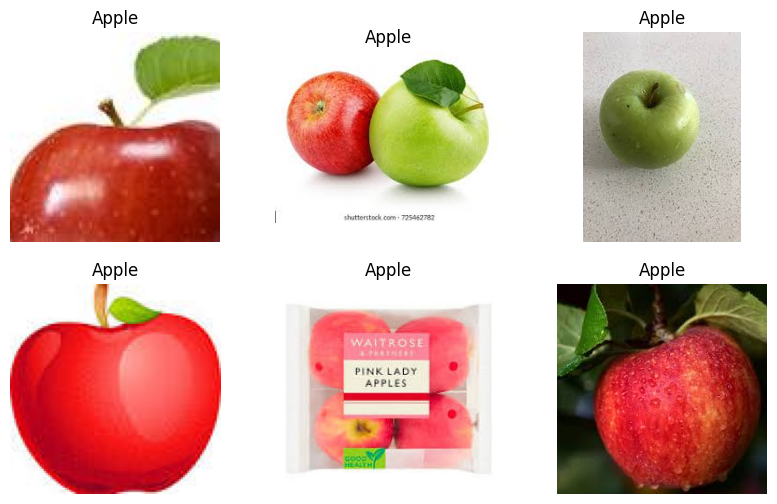

In [60]:
plt.figure(figsize=(10, 6))

for i, image_name in enumerate(os.listdir(apple_path)[:6]):

    image_path = os.path.join(apple_path, image_name)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Apple")

plt.show()

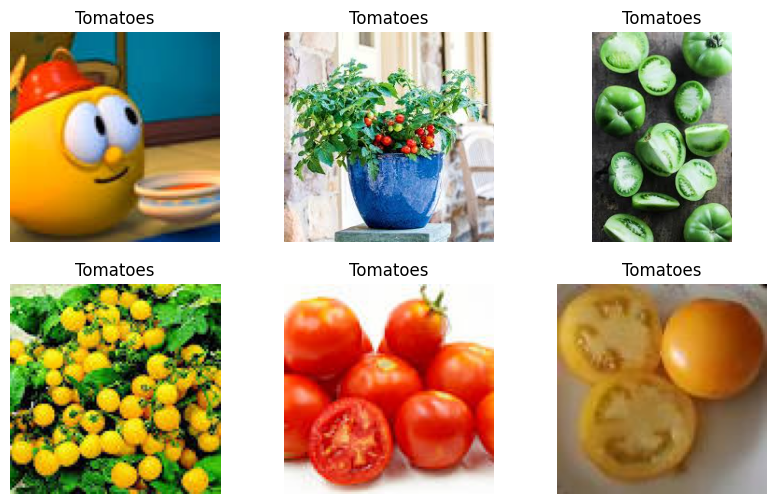

In [61]:
plt.figure(figsize=(10, 6))

for i, image_name in enumerate(os.listdir(tomatoes_path)[:6]):

    image_path = os.path.join(tomatoes_path, image_name)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Tomatoes")

plt.show()

# Creating the Train , Validation and Test set

In [62]:
IMG_SIZE = 128
batch_size= 20
import tensorflow as tf
train_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, 'train'),
    image_size=IMG_SIZE,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=42
)



Found 294 files belonging to 2 classes.
Using 236 files for training.


In [63]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, 'train'),
    image_size=IMG_SIZE,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.2,
    subset='validation',
    seed=42
)

Found 294 files belonging to 2 classes.
Using 58 files for validation.


In [64]:

test_dataset = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, 'test'),
    image_size=IMG_SIZE,
    batch_size=batch_size,
    shuffle=False
)

Found 97 files belonging to 2 classes.


In [65]:
for images, labels in train_dataset.take(1):

    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (20, 128, 128, 3)
Labels shape: (20,)


# Visualizing the final train set


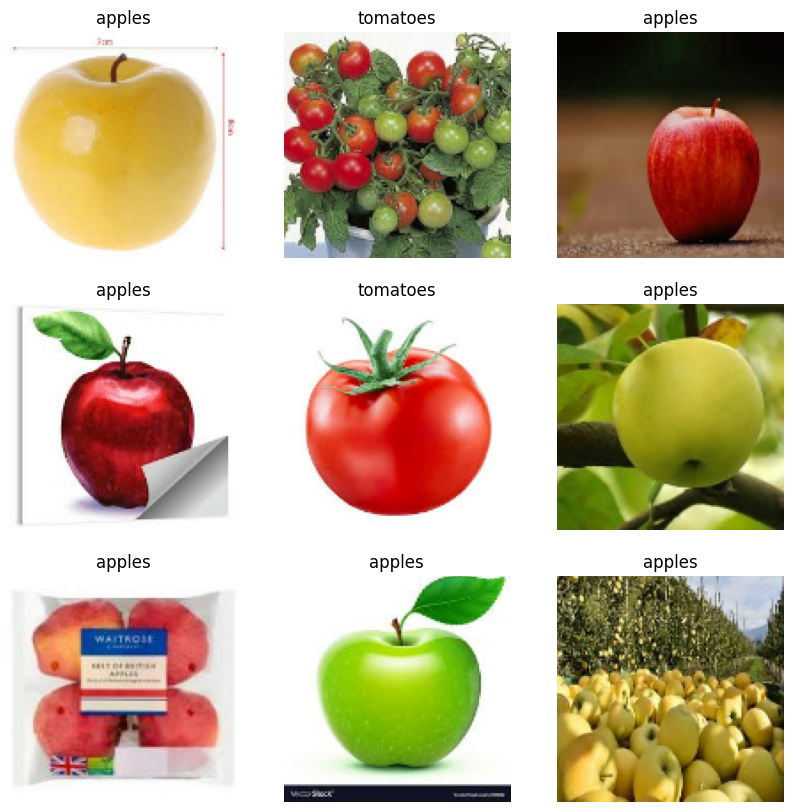

In [66]:
import matplotlib.pyplot as plt

class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## Rescaling our imagesTraining, validation, and test images must go through the same preprocessing


In [67]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

validation_dataset = validation_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)
class_names = test_dataset.class_names
test_dataset = test_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

# CNN architecture-1

In [68]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(128, 128, 3)),

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Classifier
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.5),

    # Output
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [69]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [70]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs= 33
)

Epoch 1/33
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 347ms/step - accuracy: 0.6356 - loss: 0.8361 - val_accuracy: 0.5690 - val_loss: 0.6945
Epoch 2/33
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7881 - loss: 0.4946 - val_accuracy: 0.6034 - val_loss: 0.7795
Epoch 3/33
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8008 - loss: 0.4269 - val_accuracy: 0.6034 - val_loss: 0.7265
Epoch 4/33
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8559 - loss: 0.3284 - val_accuracy: 0.6034 - val_loss: 0.7418
Epoch 5/33
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8814 - loss: 0.2704 - val_accuracy: 0.6034 - val_loss: 0.8283
Epoch 6/33
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9322 - loss: 0.1947 - val_accuracy: 0.6034 - val_loss: 0.7686
Epoch 7/33
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9110 - loss: 0.2026 - val_accuracy: 0.6034 - val_loss: 0.8694
Epoch 8/33
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9322 - loss: 0.1653 - val_accuracy: 0.6034 - 

# Overfitting creation analysis 

In [71]:
history.history.keys()


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

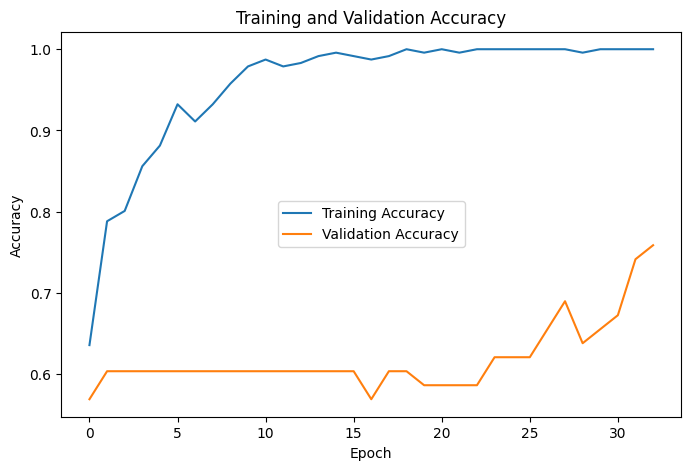

In [72]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

**We can declare it is an overfitting condition**

# Testing 

In [73]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.7526 - loss: 0.7301
Test Loss: 0.7300962209701538
Test Accuracy: 0.7525773048400879


In [74]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

## Cnfusion matrix for the model

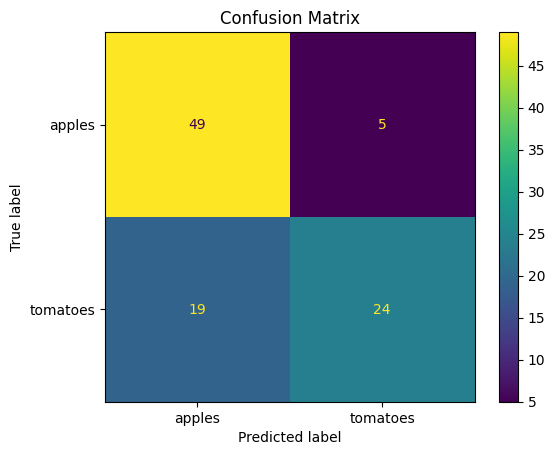

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

## Classification Report

In [79]:
from sklearn.metrics import classification_report
class_names = ['apples', 'tomatoes']
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      apples       0.72      0.91      0.80        54
    tomatoes       0.83      0.56      0.67        43

    accuracy                           0.75        97
   macro avg       0.77      0.73      0.73        97
weighted avg       0.77      0.75      0.74        97



# Improve the model with augmentation

**Images can be slightly rotated, flipped, zoomed**

In [83]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

## Architecture after augmentation

In [84]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    data_augmentation,
    
    tf.keras.layers.Conv2D(32, (3, 3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

   
    tf.keras.layers.Conv2D(64, (3, 3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

   
    tf.keras.layers.Conv2D(128, (3, 3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [85]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,217 (16.36 MB)

 Trainable params: 4,288,513 (16.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [86]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Retrain

In [92]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [93]:
history=model.fit(
    train_dataset,
    validation_data= validation_dataset,
    epochs=40,
    callbacks=[early_stopping]
)

Epoch 1/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9576 - loss: 0.1230 - val_accuracy: 0.8448 - val_loss: 0.4309
Epoch 2/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9407 - loss: 0.1309 - val_accuracy: 0.7931 - val_loss: 0.4357
Epoch 3/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9407 - loss: 0.1675 - val_accuracy: 0.8103 - val_loss: 0.3804
Epoch 4/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9576 - loss: 0.1243 - val_accuracy: 0.8621 - val_loss: 0.3624
Epoch 5/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9788 - loss: 0.0938 - val_accuracy: 0.8276 - val_loss: 0.3659
Epoch 6/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9576 - loss: 0.1286 - val_accuracy: 0.8793 - val_loss: 0.3158
Epoch 7/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9619 - loss: 0.1482 - val_accuracy: 0.8966 - val_loss: 0.3290
Epoch 8/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9492 - loss: 0.1545 - val_accuracy: 0.5172 - v

## New Architecture Visualization

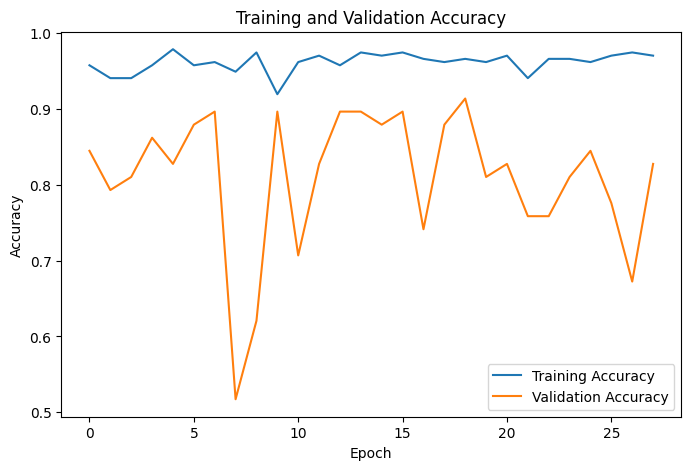

In [94]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [95]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8144 - loss: 0.5280
Test Loss: 0.5280439257621765
Test Accuracy: 0.8144329786300659


## **Yeah Accuracy is increasing**

In [96]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

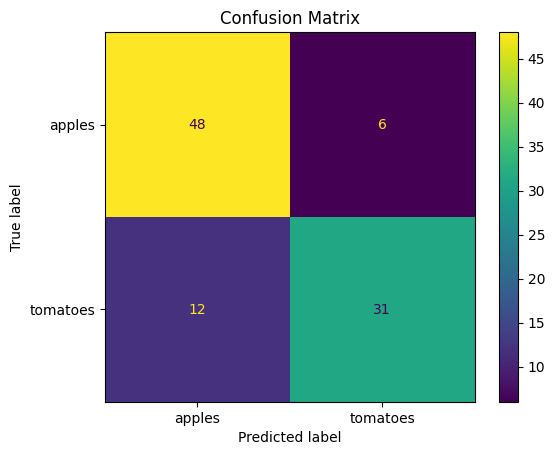

In [97]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [98]:
from sklearn.metrics import classification_report
class_names = ['apples', 'tomatoes']
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      apples       0.80      0.89      0.84        54
    tomatoes       0.84      0.72      0.78        43

    accuracy                           0.81        97
   macro avg       0.82      0.80      0.81        97
weighted avg       0.82      0.81      0.81        97



# Its time to use a pretrained model, we will use MobileNetV2

## Mobilenetv2

In [99]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,#We don't want MobileNet's original classification layer
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [100]:
base_model.trainable = False
model_transfer = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    # Our datset were already normalized to [0, 1]
    # But MobileNetV2 expects [-1, 1]
    tf.keras.layers.Rescaling(
        scale=2.0,
        offset=-1.0
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [101]:
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_transfer.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [102]:
history_transfer = model_transfer.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25
)

Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.6017 - loss: 0.7337 - val_accuracy: 0.7069 - val_loss: 0.6148
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6864 - loss: 0.6050 - val_accuracy: 0.7931 - val_loss: 0.5242
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7288 - loss: 0.5720 - val_accuracy: 0.8103 - val_loss: 0.4662
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7458 - loss: 0.4833 - val_accuracy: 0.8621 - val_loss: 0.4210
Epoch 5/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8475 - loss: 0.3895 - val_accuracy: 0.8621 - val_loss: 0.3888
Epoch 6/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8602 - loss: 0.3549 - val_accuracy: 0.8966 - val_loss: 0.3708
Epoch 7/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8771 - loss: 0.3283 - val_accuracy: 0.8966 - val_loss: 0.3580
Epoch 8/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9110 - loss: 0.2867 - val_accuracy: 0.9138 - va

In [105]:
test_loss, test_accuracy = model_transfer.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 754ms/step - accuracy: 0.8454 - loss: 0.3388
Test Loss: 0.33880728483200073
Test Accuracy: 0.8453608155250549


In [103]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model_transfer.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

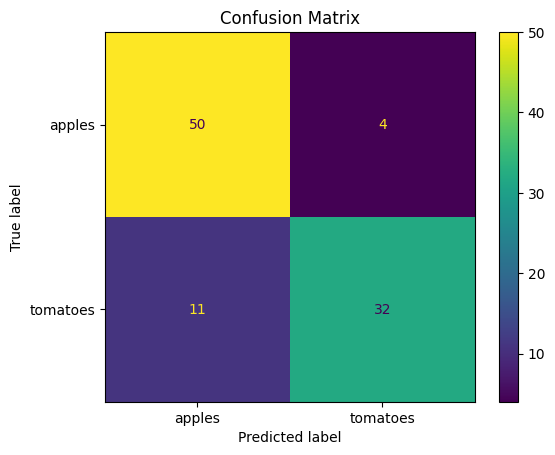

In [104]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

## **Fine Tuning**

Early layer learns - Edges ,Lines, Corners ,Basic textures

Later Layer learns - Shapes
Object parts
Complex textures
Patterns

**Use MobileNetV2's existing knowledge and learn how to classify my classes**

**Now slightly modify some of MobileNetV2's later knowledge so it works even better for my specific classes**

In [106]:

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_finetune = model_transfer.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20
)

Epoch 1/20


2026-09-08 21:38:38.549629: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 21:38:38.750606: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 6/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8647 - loss: 0.3341 

2026-09-08 21:38:45.475448: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 21:38:45.673325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 21:38:45.869983: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 21:38:46.069022: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-08 21:38:46.268677: E external/local_xla/xla/stream_

12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8729 - loss: 0.3073 - val_accuracy: 0.9483 - val_loss: 0.2310
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8814 - loss: 0.2826 - val_accuracy: 0.9483 - val_loss: 0.2258
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9195 - loss: 0.2235 - val_accuracy: 0.9483 - val_loss: 0.2214
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9364 - loss: 0.2370 - val_accuracy: 0.9483 - val_loss: 0.2175
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9110 - loss: 0.2333 - val_accuracy: 0.9483 - val_loss: 0.2144
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9407 - loss: 0.1828 - val_accuracy: 0.9483 - val_loss: 0.2105
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9237 - loss: 0.1950 - val_accuracy: 0.9655 - val_loss: 0.2059
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9492 - loss: 0.1582 - val_accuracy: 0.9655 - val_loss: 0.2

# The Ultimate Result 

In [109]:
cnn_loss, cnn_accuracy = model.evaluate(test_dataset)

transfer_loss, transfer_accuracy = model_transfer.evaluate(test_dataset)

print("CNN Test Accuracy:", cnn_accuracy)
print("Mobilenetv2 Test Accuracy:", transfer_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8144 - loss: 0.5280
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8557 - loss: 0.3340
CNN Test Accuracy: 0.8144329786300659
Mobilenetv2 Test Accuracy: 0.8556700944900513
